In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
df=pd.read_csv("/content/pizza_sales.csv")

Import Raw Data


In [26]:
df=pd.read_csv("/content/pizza_sales.csv")

MetaData of Raw Data


In [27]:
df.head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,01-01-2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,01-01-2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,01-01-2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,01-01-2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,01-01-2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [28]:
df.shape

(48620, 12)

In [29]:
df.columns

Index(['pizza_id', 'order_id', 'pizza_name_id', 'quantity', 'order_date',
       'order_time', 'unit_price', 'total_price', 'pizza_size',
       'pizza_category', 'pizza_ingredients', 'pizza_name'],
      dtype='object')

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  int64  
 1   order_id           48620 non-null  int64  
 2   pizza_name_id      48620 non-null  object 
 3   quantity           48620 non-null  int64  
 4   order_date         48620 non-null  object 
 5   order_time         48620 non-null  object 
 6   unit_price         48620 non-null  float64
 7   total_price        48620 non-null  float64
 8   pizza_size         48620 non-null  object 
 9   pizza_category     48620 non-null  object 
 10  pizza_ingredients  48620 non-null  object 
 11  pizza_name         48620 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 4.5+ MB


Data Types in Raw Data

In [31]:
df.dtypes

,0
pizza_id,int64
order_id,int64
pizza_name_id,object
quantity,int64
order_date,object
order_time,object
unit_price,float64
total_price,float64
pizza_size,object
pizza_category,object


In [32]:
df.describe()

,pizza_id,order_id,quantity,unit_price,total_price
count,48620.000000,48620.000000,48620.000000,48620.000000,48620.000000
mean,24310.500000,10701.479761,1.019622,16.494132,16.821474
std,14035.529381,6180.119770,0.143077,3.621789,4.437398
min,1.000000,1.000000,1.000000,9.750000,9.750000
25%,12155.750000,5337.000000,1.000000,12.750000,12.750000
50%,24310.500000,10682.500000,1.000000,16.500000,16.500000
75%,36465.250000,16100.000000,1.000000,20.250000,20.500000
max,48620.000000,21350.000000,4.000000,35.950000,83.000000


KPIs

In [36]:
total_revunue = df[ 'total_price'].sum()
total_pizzas_sold =df['quantity'].sum()
total_orders =df['order_id'].nunique()
avg_pizzas_per_order = total_pizzas_sold / total_orders
print(f"Total Revenue: ${total_revunue:,.2f}")
print(f"Total Pizzas sold: ${total_pizzas_sold :,}")
print(f"Total Orders: ${total_orders :,.2f}")
print(f"Average_pizza_per_order:{avg_pizzas_per_order:,.2f}")

Total Revenue: $817,860.05
Total Pizzas sold: $49,574
Total Orders: $21,350.00
Average_pizza_per_order:2.32


Chart's


Ingredient Analyst


In [37]:
ingredient = (
    df['pizza_ingredients']
    .str.split(',')
    .explode()
    .value_counts()
    .reset_index()
    .rename(columns={'index' :'Count', 'pizza_ingredients':'Indegredients'})
)
print(ingredient.head())

  Indegredients  count
0        Garlic  27422
1      Tomatoes  23694
2    Red Onions  19547
3   Red Peppers  16284
4       Chicken   8443


Daily Trends - Total Order

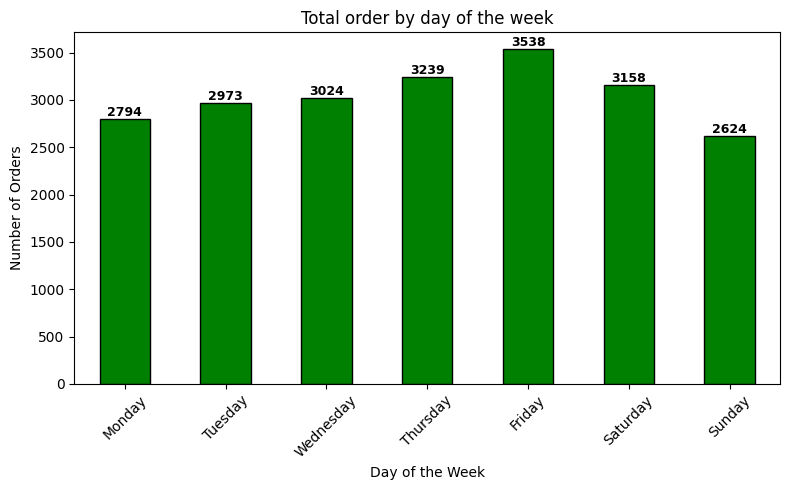

In [39]:
from pandas.core import groupby
df['order_date']=pd.to_datetime(df['order_date'], dayfirst=True)
df['day_name'] = df['order_date'].dt.day_name()
weekday_order =['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['day_name'] = pd.Categorical(df['day_name'], categories=weekday_order, ordered=True)
orders_by_day=df.groupby('day_name',observed=False)['order_id'].nunique()
ax =orders_by_day.plot(kind='bar',figsize=(8,5), color='green', edgecolor = 'black')

plt.title('Total order by day of the week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)

for i,val in enumerate(orders_by_day):
  ax.text(i,val,str(val),ha='center',va='bottom',fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

Daily Trends - Total Revenue

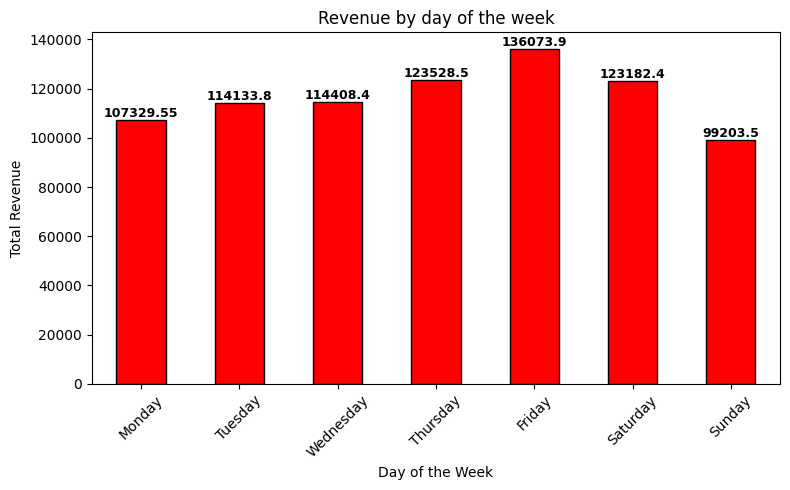

In [42]:
from pandas.core import groupby
df['order_date']=pd.to_datetime(df['order_date'], dayfirst=True)
df['day_name'] = df['order_date'].dt.day_name()
weekday_order =['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['day_name'] = pd.Categorical(df['day_name'], categories=weekday_order, ordered=True)
orders_by_day=df.groupby('day_name',observed=False)['total_price'].sum()
ax =orders_by_day.plot(kind='bar',figsize=(8,5), color='red', edgecolor = 'black')

plt.title('Revenue by day of the week')
plt.xlabel('Day of the Week')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)

for i,val in enumerate(orders_by_day):
  ax.text(i,val,str(val),ha='center',va='bottom',fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

Hourly Trend - Total orders

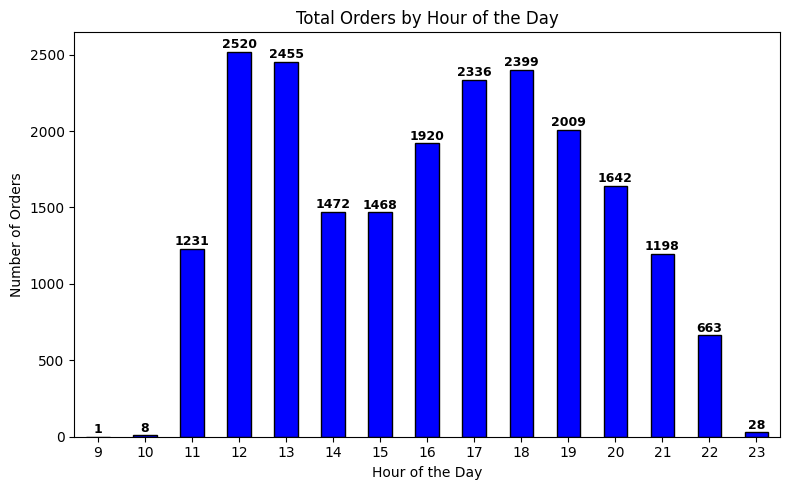

In [45]:
df['order_time'] = pd.to_datetime(
    df['order_time'],
    format='%H:%M:%S'
)

df['order_hour'] = df['order_time'].dt.hour

orders_by_hour = (
    df.groupby('order_hour')['order_id']
    .nunique()
)

ax = orders_by_hour.plot(
    kind='bar',
    figsize=(8, 5),
    color='blue',
    edgecolor='black'
)

plt.title('Total Orders by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)

for i, val in enumerate(orders_by_hour):
    ax.text(
        i,
        val + 5,
        str(val),
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

Mountly Trend


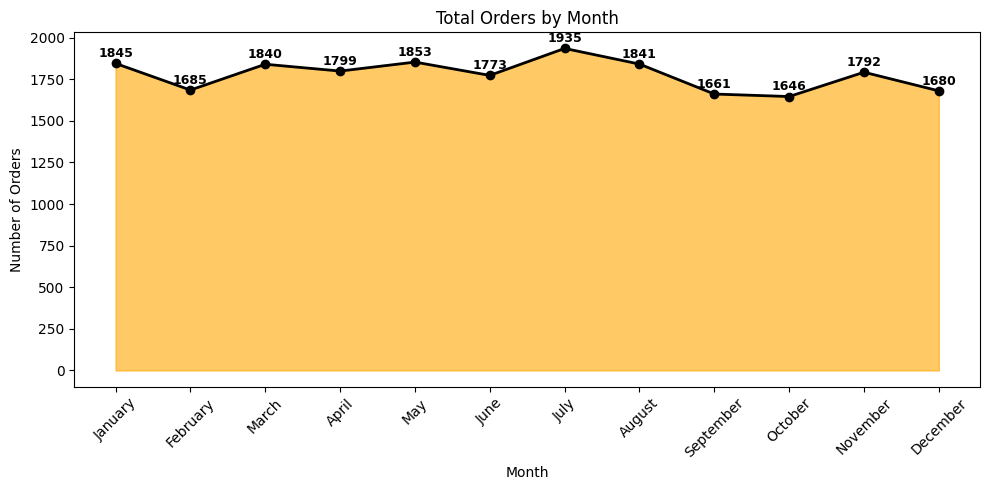

In [46]:
df['order_date'] = pd.to_datetime(
    df['order_date'],
    dayfirst=True
)

df['month_name'] = df['order_date'].dt.month_name()

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

df['month_name'] = pd.Categorical(
    df['month_name'],
    categories=month_order,
    ordered=True
)

orders_by_month = df.groupby(
    'month_name',
    observed=False
)['order_id'].nunique()

plt.figure(figsize=(10, 5))

plt.fill_between(
    orders_by_month.index,
    orders_by_month.values,
    color="orange",
    alpha=0.6
)

plt.plot(
    orders_by_month.index,
    orders_by_month.values,
    color="black",
    linewidth=2,
    marker='o'
)

plt.title("Total Orders by Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

for i, val in enumerate(orders_by_month):
    plt.text(
        i,
        val + 20,
        str(val),
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

Sales by category

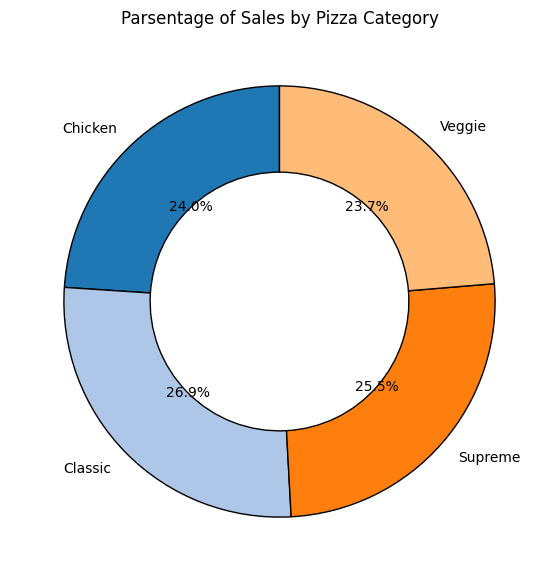

In [50]:
category_sales =df.groupby('pizza_category')['total_price'].sum()
category_pct = category_sales / category_sales.sum() * 100
plt.figure(figsize=(7,7))
colors =plt.get_cmap('tab20').colors
plt.pie(category_pct,labels=category_pct.index,autopct='%1.1f%%',startangle=90,colors=colors,wedgeprops={'edgecolor':'black','width':0.4})
plt.title('Parsentage of Sales by Pizza Category')
plt.show()

Sales by Pizza size & Category

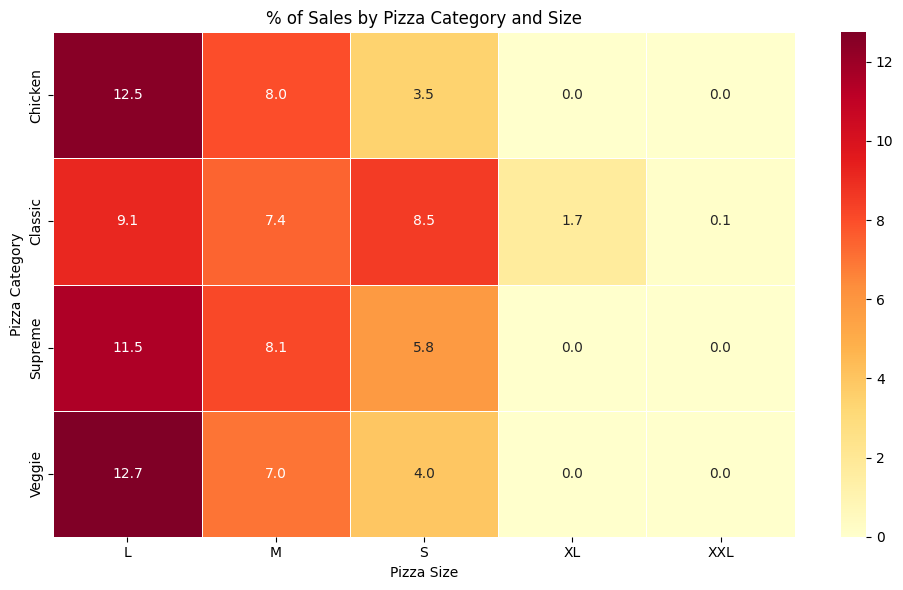

In [59]:
sales_pivot = df.pivot_table(
    index='pizza_category',
    columns='pizza_size',
    values='total_price',
    aggfunc='sum',
    fill_value=0
)

sales_pct = (
    sales_pivot / sales_pivot.to_numpy().sum()
) * 100

plt.figure(figsize=(10, 6))

sns.heatmap(
    sales_pct,
    annot=True,
    cmap='YlOrRd',
    fmt='.1f',
    linewidths=0.5
)

plt.title('% of Sales by Pizza Category and Size')
plt.xlabel('Pizza Size')
plt.ylabel('Pizza Category')

plt.tight_layout()
plt.show()

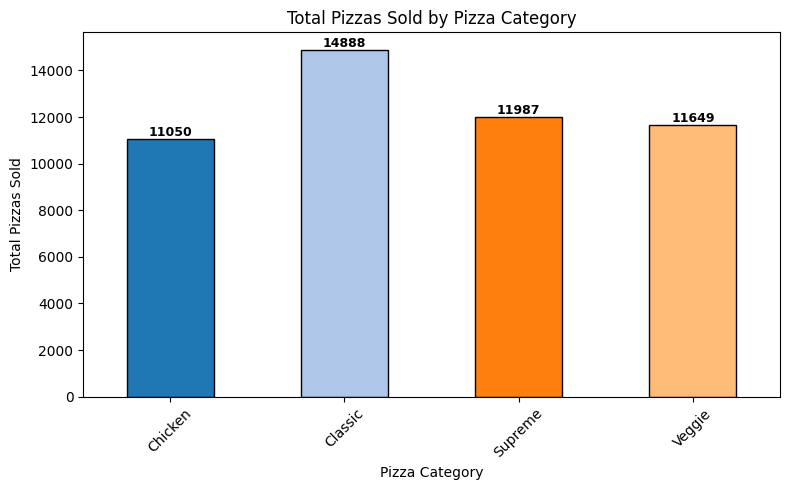

In [60]:
pizzas_by_category = df.groupby('pizza_category')['quantity'].sum()

colors = list(plt.get_cmap('tab20').colors)

colors = colors[:len(pizzas_by_category)]

ax = pizzas_by_category.plot(
    kind='bar',
    figsize=(8, 5),
    color=colors,
    edgecolor='black'
)

plt.title("Total Pizzas Sold by Pizza Category")
plt.xlabel("Pizza Category")
plt.ylabel("Total Pizzas Sold")
plt.xticks(rotation=45)

for i, val in enumerate(pizzas_by_category):
    plt.text(
        i,
        val + 5,
        str(val),
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

Top 5 Best selling Pizzas -Total Orders

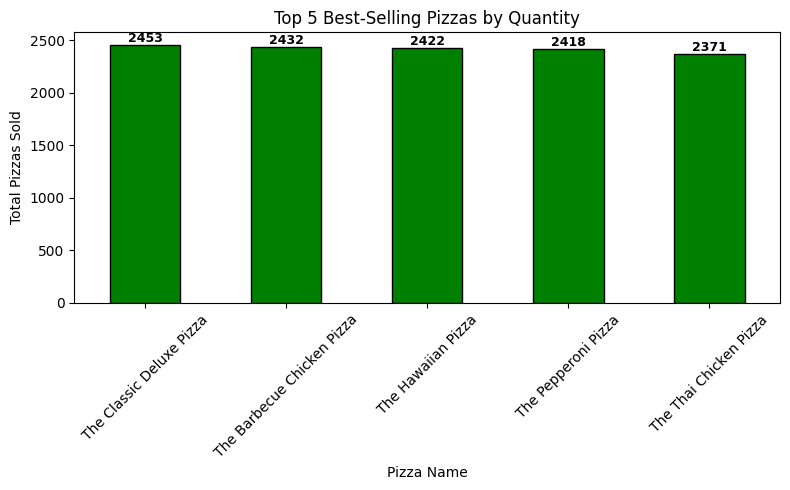

In [62]:
pizzas_by_name = (
    df.groupby('pizza_name')['quantity']
    .sum()
)

top_5_pizzas = (
    pizzas_by_name
    .sort_values(ascending=False)
    .head(5)
)

ax = top_5_pizzas.plot(
    kind='bar',
    figsize=(8, 5),
    color='green',
    edgecolor='black'
)

plt.title('Top 5 Best-Selling Pizzas by Quantity')

plt.xlabel('Pizza Name')
plt.ylabel('Total Pizzas Sold')

plt.xticks(rotation=45)

for i, val in enumerate(top_5_pizzas):
    ax.text(
        i,
        val,
        str(val),
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

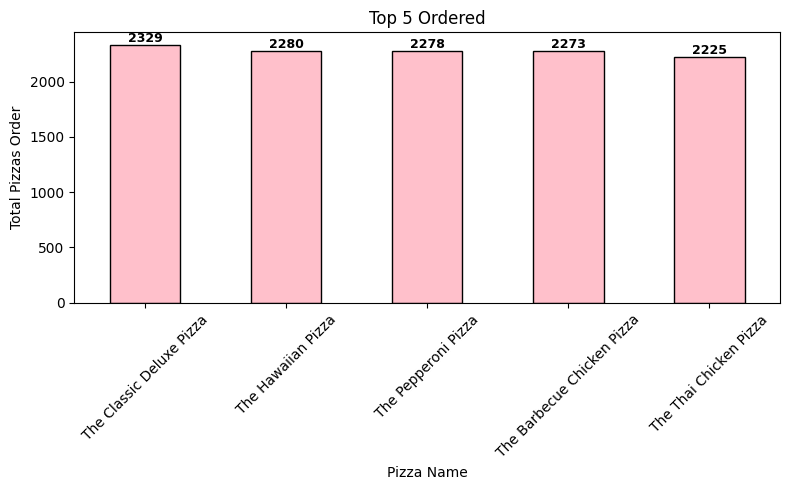

In [66]:
pizzas_by_name = (
    df.groupby('pizza_name')['order_id'].nunique()

)

top_5_pizzas = (
    pizzas_by_name
    .sort_values(ascending=False)
    .head(5)
)

ax = top_5_pizzas.plot(
    kind='bar',
    figsize=(8, 5),
    color='pink',
    edgecolor='black'
)

plt.title('Top 5 Ordered')

plt.xlabel('Pizza Name')
plt.ylabel('Total Pizzas Order')

plt.xticks(rotation=45)

for i, val in enumerate(top_5_pizzas):
    ax.text(
        i,
        val,
        str(val),
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()